# Notebook 05 — Eindvergelijking & Conclusies

**Project:** ML Regressie op YouTube trending video data  
 
**Doel van deze notebook:** Alle modellen naast elkaar plaatsen, het beste model analyseren en een concreet antwoord formuleren op de onderzoeksvraag.

---

### Onderzoeksvraag
> *"Welke factoren voorspellen of een trending YouTube video hoog scoort op engagement — en verschilt dit per categorie, taal of regio?"*

## 1. Setup & resultaten laden

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.bbox'] = 'tight'

import os
os.makedirs('../output/figures', exist_ok=True)

with open('../output/models/train_test_data.pkl', 'rb') as f:
    data = pickle.load(f)

with open('../output/models/results_nb04.pkl', 'rb') as f:
    results = pickle.load(f)

with open('../output/models/best_xgb_pipe.pkl', 'rb') as f:
    best_xgb_pipe = pickle.load(f)

with open('../output/models/best_rf_pipe.pkl', 'rb') as f:
    best_rf_pipe = pickle.load(f)

X_train = data['X_train']
X_test  = data['X_test']
y_train = data['y_train']
y_test  = data['y_test']
feature_names = data['feature_names']

print(f'{len(results)} modellen geladen uit notebooks 03 en 04.')

13 modellen geladen uit notebooks 03 en 04.


## 2. Grote vergelijkingstabel — alle modellen

We vergelijken alle modellen op:
- **R²** — hoeveel variatie verklaart het model?
- **MAE** — gemiddelde fout in de eenheden van engagement_score
- **RMSE** — straft grote fouten harder
- **CV R²** — prestatie op de trainset via cross-validatie (detecteert overfitting)

In [2]:
results_df = pd.DataFrame(results).T.round(4)
results_df = results_df.sort_values('R²', ascending=False)
results_df['Overfitting?'] = (results_df['CV R² (train)'] - results_df['R²']).apply(
    lambda x: '⚠️ ja' if x > 0.05 else '✓ nee'
)

print('Alle modellen gesorteerd op Test R²:')
display(results_df)

best_model_name = results_df.index[0]
best_r2 = results_df.iloc[0]['R²']
print(f'\n🏆 Beste model: {best_model_name}  (R² = {best_r2:.4f})')

Alle modellen gesorteerd op Test R²:


,R²,MAE,RMSE,CV R² (train),Overfitting?
Polynomiale regressie (degree=2),0.7112,0.9257,1.2342,0.6981,✓ nee
XGBoost (getuned),0.7091,0.9409,1.2386,0.6989,✓ nee
Polynomiale regressie (degree=3),0.7077,0.9321,1.2416,0.6929,✓ nee
Lineaire regressie,0.7039,0.9585,1.2497,0.6912,✓ nee
"ElasticNet (α=0.01, l1=0.7)",0.7033,0.9631,1.2510,0.6930,✓ nee
Lasso (alpha=0.01),0.7027,0.9641,1.2523,0.6929,✓ nee
Ridge (alpha=100.0),0.7022,0.9626,1.2532,0.6911,✓ nee
Decision Tree (depth=4),0.7018,0.9311,1.2540,0.6972,✓ nee
XGBoost,0.6997,0.9441,1.2584,0.6851,✓ nee
Random Forest (getuned),0.6996,0.9500,1.2588,0.6894,✓ nee



🏆 Beste model: Polynomiale regressie (degree=2)  (R² = 0.7112)


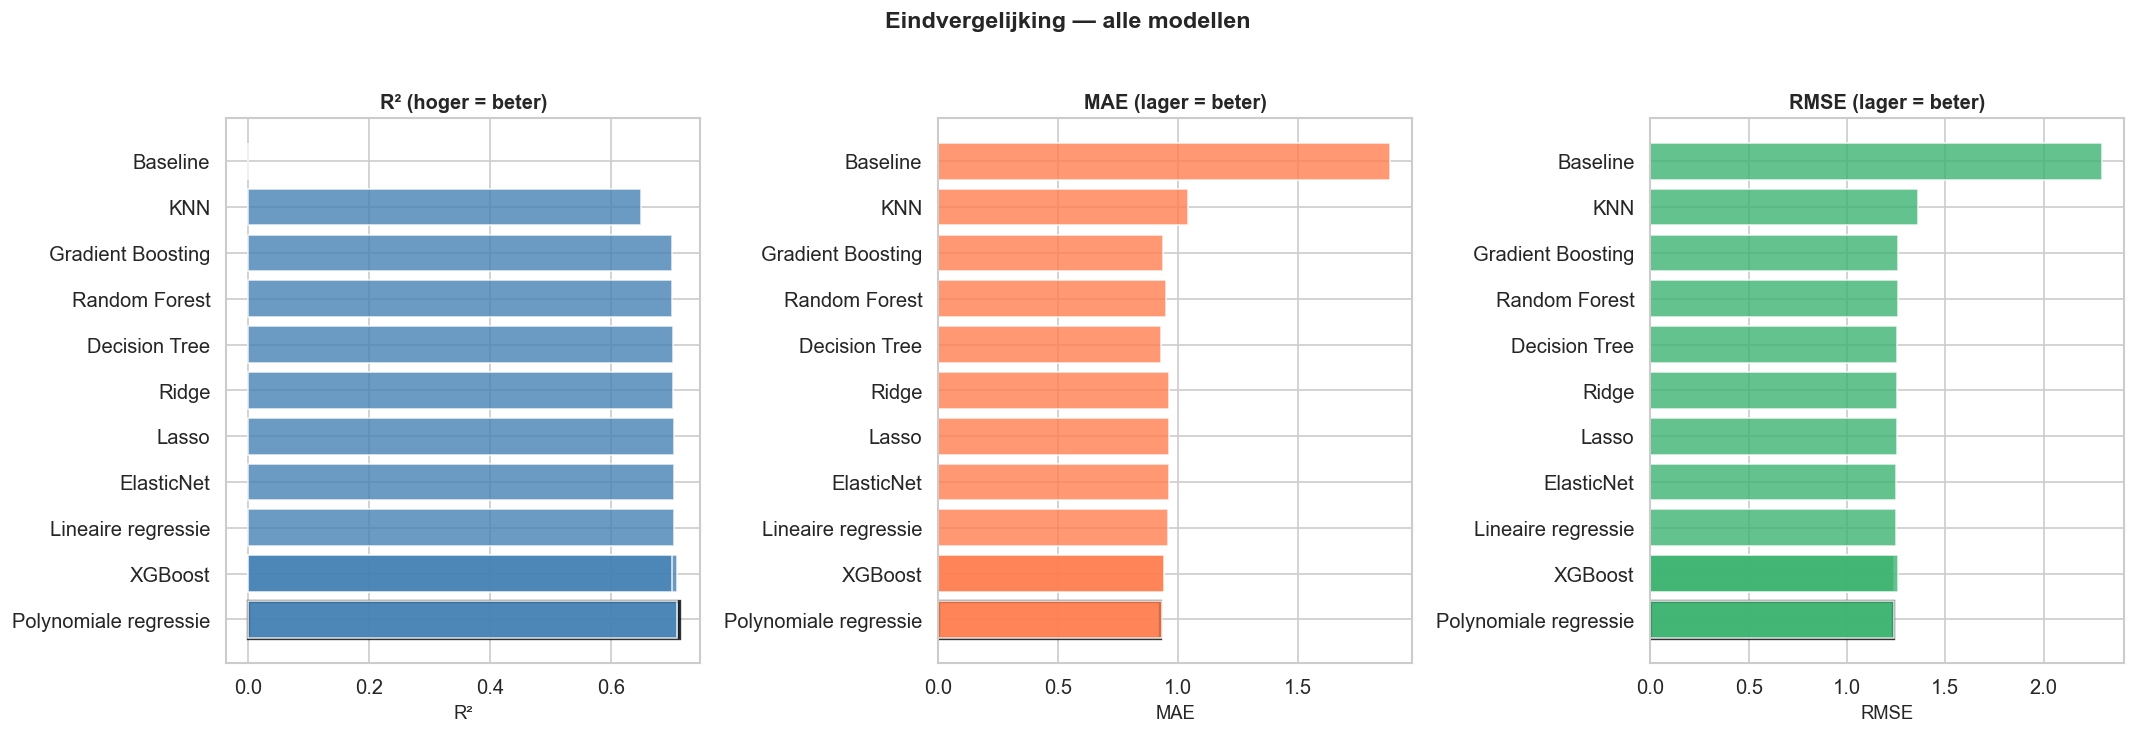

In [3]:
# Visuele vergelijking — horizontale barplots
fig, axes = plt.subplots(1, 3, figsize=(18, max(6, len(results_df) * 0.45)))

short = [n.split('(')[0].strip() for n in results_df.index]
palette = sns.color_palette('muted', len(results_df))

for ax, metric, color_base in zip(axes,
                                   ['R²', 'MAE', 'RMSE'],
                                   ['steelblue', 'coral', 'mediumseagreen']):
    vals = results_df[metric]
    bars = ax.barh(short, vals, color=color_base, alpha=0.8)
    ax.set_xlabel(metric, fontsize=11)
    better = 'hoger = beter' if metric == 'R²' else 'lager = beter'
    ax.set_title(f'{metric} ({better})', fontsize=12, fontweight='bold')
    # highlight beste
    best_idx = vals.argmax() if metric == 'R²' else vals.argmin()
    bars[best_idx].set_edgecolor('black')
    bars[best_idx].set_linewidth(2)

plt.suptitle('Eindvergelijking — alle modellen', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../output/figures/05_eindvergelijking_alle_modellen.png')
plt.show()

## 3. Beste model in detail

We analyseren het winnende model dieper:
1. Predicted vs Actual — ziet de voorspelling er goed uit?
2. Residuplot — zijn de fouten willekeurig verdeeld?
3. Foutdistributie — hoe groot zijn de fouten typisch?

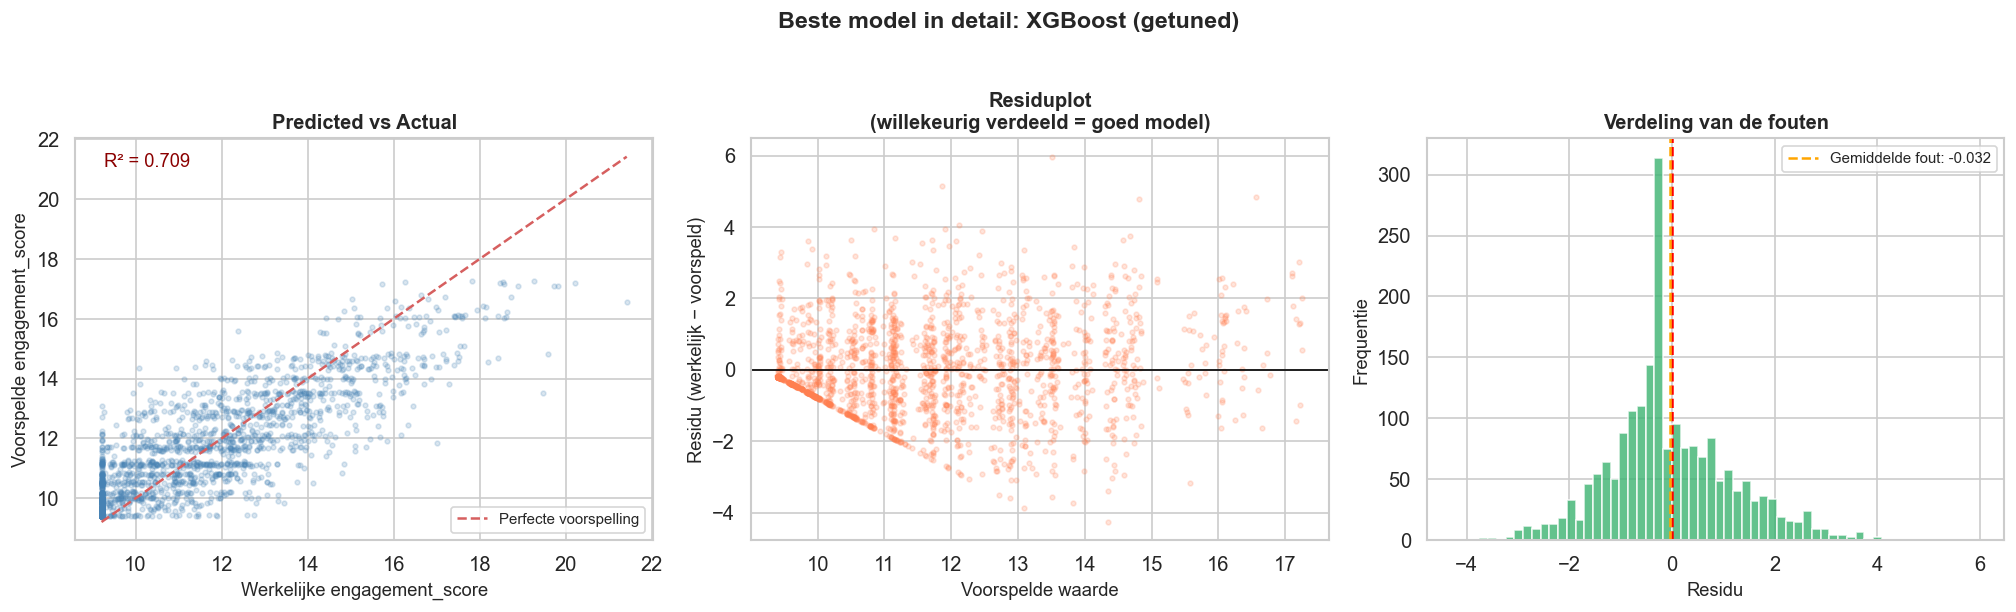

Prestatie XGBoost (getuned) op testset:
  R²   = 0.7091
  MAE  = 0.9409  → gemiddelde fout van 0.9409 engagement-punten
  RMSE = 1.2386


In [4]:
# Beste model selecteren
if 'XGBoost (getuned)' in results_df.index[:3]:
    best_pipe = best_xgb_pipe
    best_label = 'XGBoost (getuned)'
else:
    best_pipe = best_rf_pipe
    best_label = 'Random Forest (getuned)'

best_pipe.fit(X_train, y_train)
y_pred = best_pipe.predict(X_test)
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Predicted vs Actual
axes[0].scatter(y_test, y_pred, alpha=0.2, s=8, color='steelblue')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfecte voorspelling')
axes[0].set_xlabel('Werkelijke engagement_score', fontsize=11)
axes[0].set_ylabel('Voorspelde engagement_score', fontsize=11)
axes[0].set_title('Predicted vs Actual', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
r2 = r2_score(y_test, y_pred)
axes[0].text(0.05, 0.93, f'R² = {r2:.3f}', transform=axes[0].transAxes,
             fontsize=11, color='darkred')

# Residuplot
axes[1].scatter(y_pred, residuals, alpha=0.2, s=8, color='coral')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_xlabel('Voorspelde waarde', fontsize=11)
axes[1].set_ylabel('Residu (werkelijk − voorspeld)', fontsize=11)
axes[1].set_title('Residuplot\n(willekeurig verdeeld = goed model)', fontsize=12, fontweight='bold')

# Foutdistributie
axes[2].hist(residuals, bins=60, color='mediumseagreen', edgecolor='white', alpha=0.8)
axes[2].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[2].axvline(residuals.mean(), color='orange', linestyle='--',
                label=f'Gemiddelde fout: {residuals.mean():.3f}')
axes[2].set_xlabel('Residu', fontsize=11)
axes[2].set_ylabel('Frequentie', fontsize=11)
axes[2].set_title('Verdeling van de fouten', fontsize=12, fontweight='bold')
axes[2].legend(fontsize=9)

plt.suptitle(f'Beste model in detail: {best_label}', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../output/figures/05_beste_model_analyse.png')
plt.show()

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'Prestatie {best_label} op testset:')
print(f'  R²   = {r2:.4f}')
print(f'  MAE  = {mae:.4f}  → gemiddelde fout van {mae:.4f} engagement-punten')
print(f'  RMSE = {rmse:.4f}')

## 4. Antwoord op de onderzoeksvraag

### Welke factoren bepalen engagement?

Op basis van de feature importance van het beste model geven we een concreet antwoord.

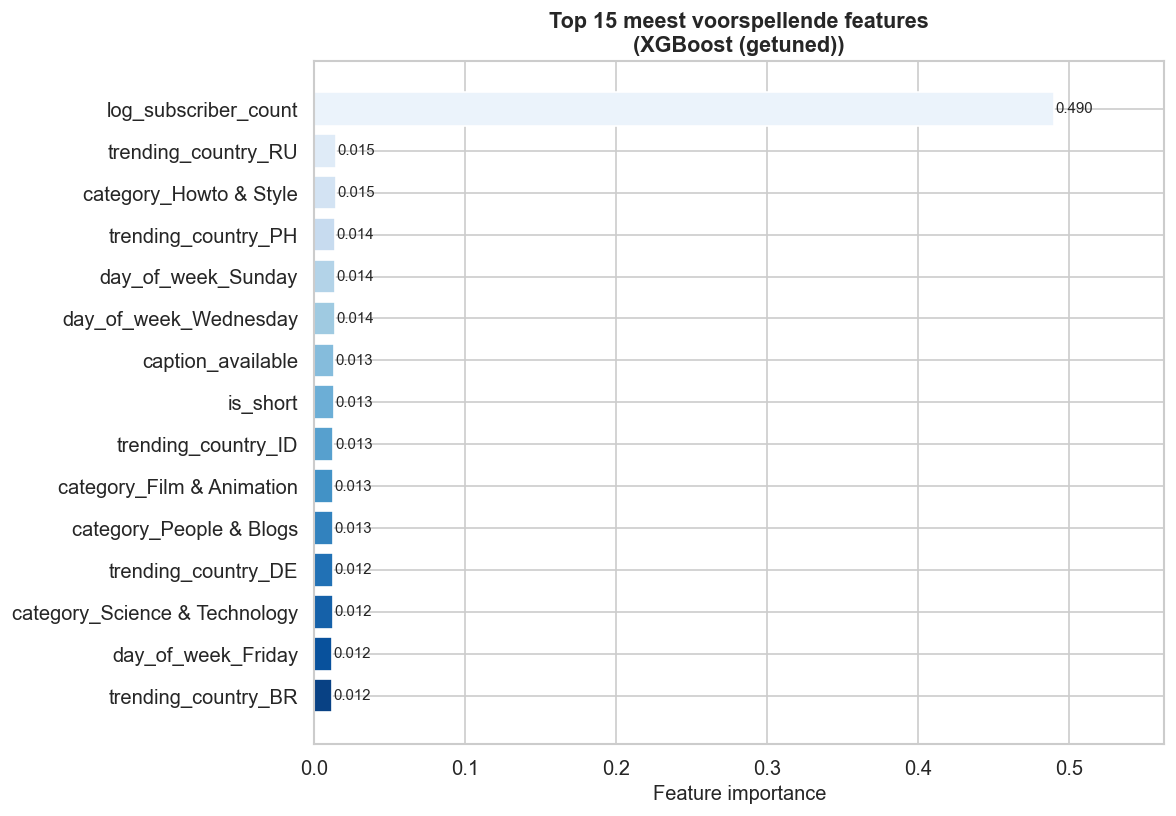

Top 10 features:


,feature,importance
0,log_subscriber_count,0.4895
1,trending_country_RU,0.0147
2,category_Howto & Style,0.0147
3,trending_country_PH,0.0141
4,day_of_week_Sunday,0.0140
5,day_of_week_Wednesday,0.0140
6,caption_available,0.0135
7,is_short,0.0132
8,trending_country_ID,0.0129
9,category_Film & Animation,0.0128


In [5]:
importances = best_pipe.named_steps['model'].feature_importances_
imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
imp_df = imp_df.sort_values('importance', ascending=False)

top15 = imp_df.head(15).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top15['feature'], top15['importance'],
               color=sns.color_palette('Blues_r', 15))
ax.set_xlabel('Feature importance', fontsize=12)
ax.set_title(f'Top 15 meest voorspellende features\n({best_label})',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, top15['importance'].max() * 1.15)

for bar, val in zip(bars, top15['importance']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../output/figures/05_feature_importance_finaal.png')
plt.show()

print('Top 10 features:')
display(imp_df.head(10).reset_index(drop=True).round(4))

## 5. Verschilt engagement per categorie, taal en regio?

We beantwoorden het tweede deel van de onderzoeksvraag:  
zijn de voorspellingen van het model consistent over categorieën, talen en regio's,  
of presteert het model voor sommige groepen beter dan voor andere?

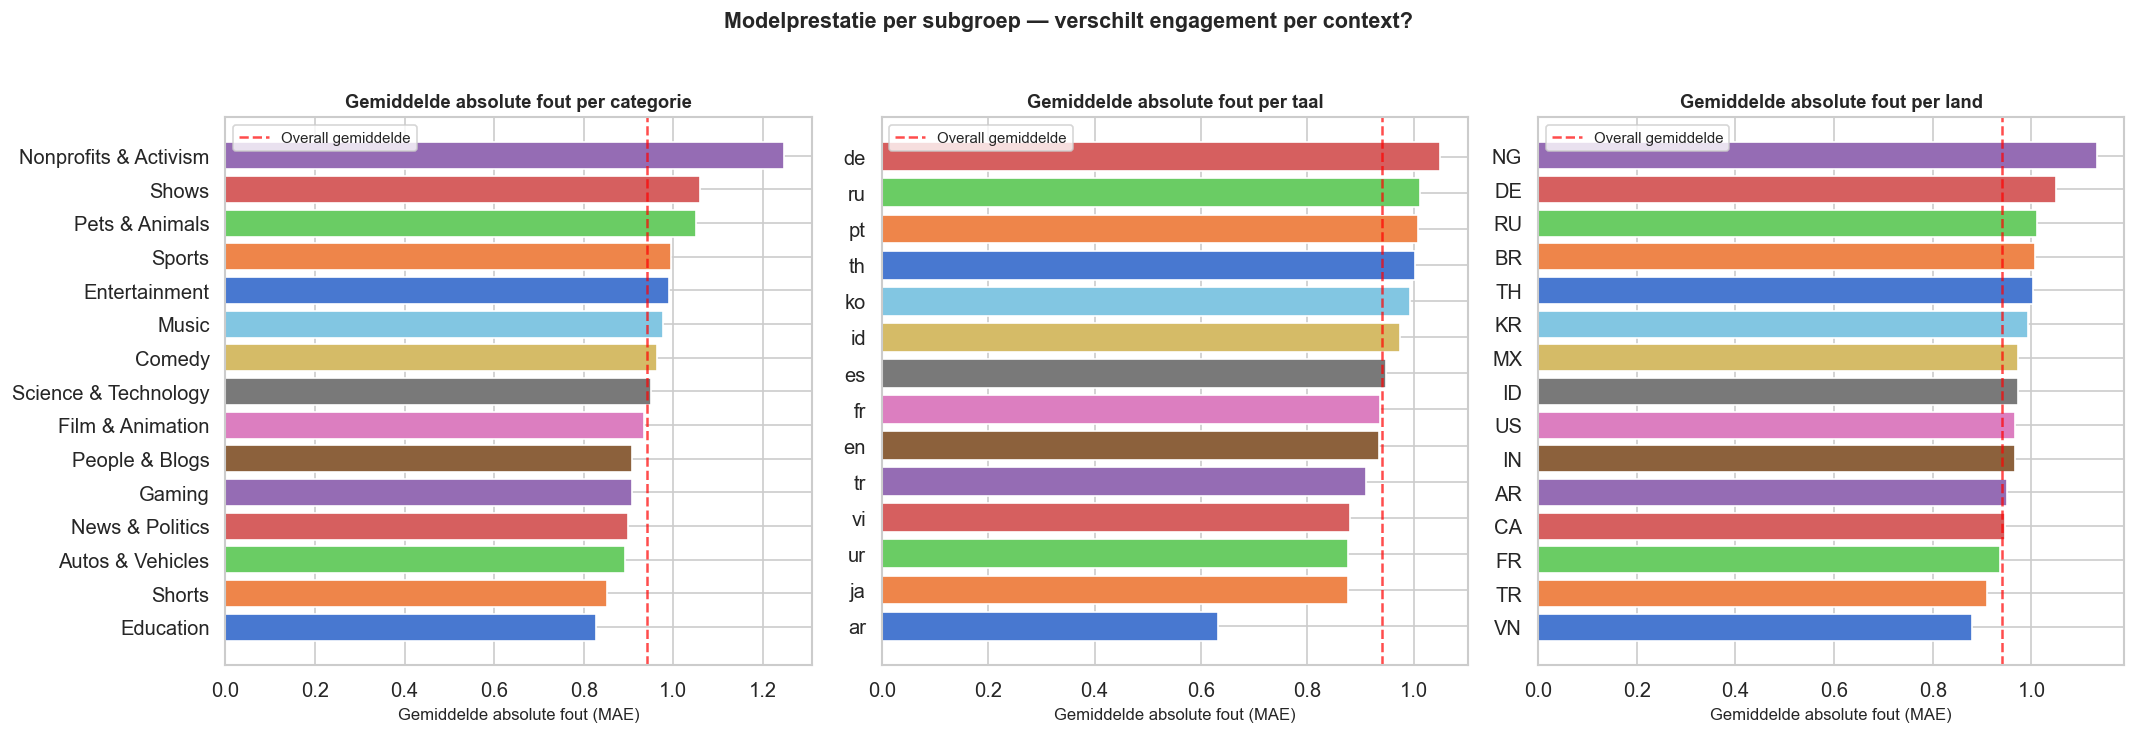

In [6]:
# Laad originele dataset om subgroep-analyse te doen
df_orig = pd.read_csv('../data/trending_videos.csv')
test_idx = y_test.index

analysis_df = df_orig.loc[test_idx, ['category', 'language', 'trending_country']].copy()
analysis_df['werkelijk']  = y_test.values
analysis_df['voorspeld']  = y_pred
analysis_df['abs_fout']   = np.abs(analysis_df['werkelijk'] - analysis_df['voorspeld'])

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, col, title in zip(axes,
                           ['category', 'language', 'trending_country'],
                           ['Gemiddelde absolute fout per categorie',
                            'Gemiddelde absolute fout per taal',
                            'Gemiddelde absolute fout per land']):
    group = analysis_df.groupby(col)['abs_fout'].mean().sort_values(ascending=True)
    if len(group) > 15:
        group = group.tail(15)
    ax.barh(group.index, group.values,
            color=sns.color_palette('muted', len(group)))
    ax.axvline(analysis_df['abs_fout'].mean(), color='red', linestyle='--',
               alpha=0.7, label='Overall gemiddelde')
    ax.set_xlabel('Gemiddelde absolute fout (MAE)', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Modelprestatie per subgroep — verschilt engagement per context?',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../output/figures/05_subgroep_analyse.png')
plt.show()

## 6. Modelevolutie — van baseline naar beste model

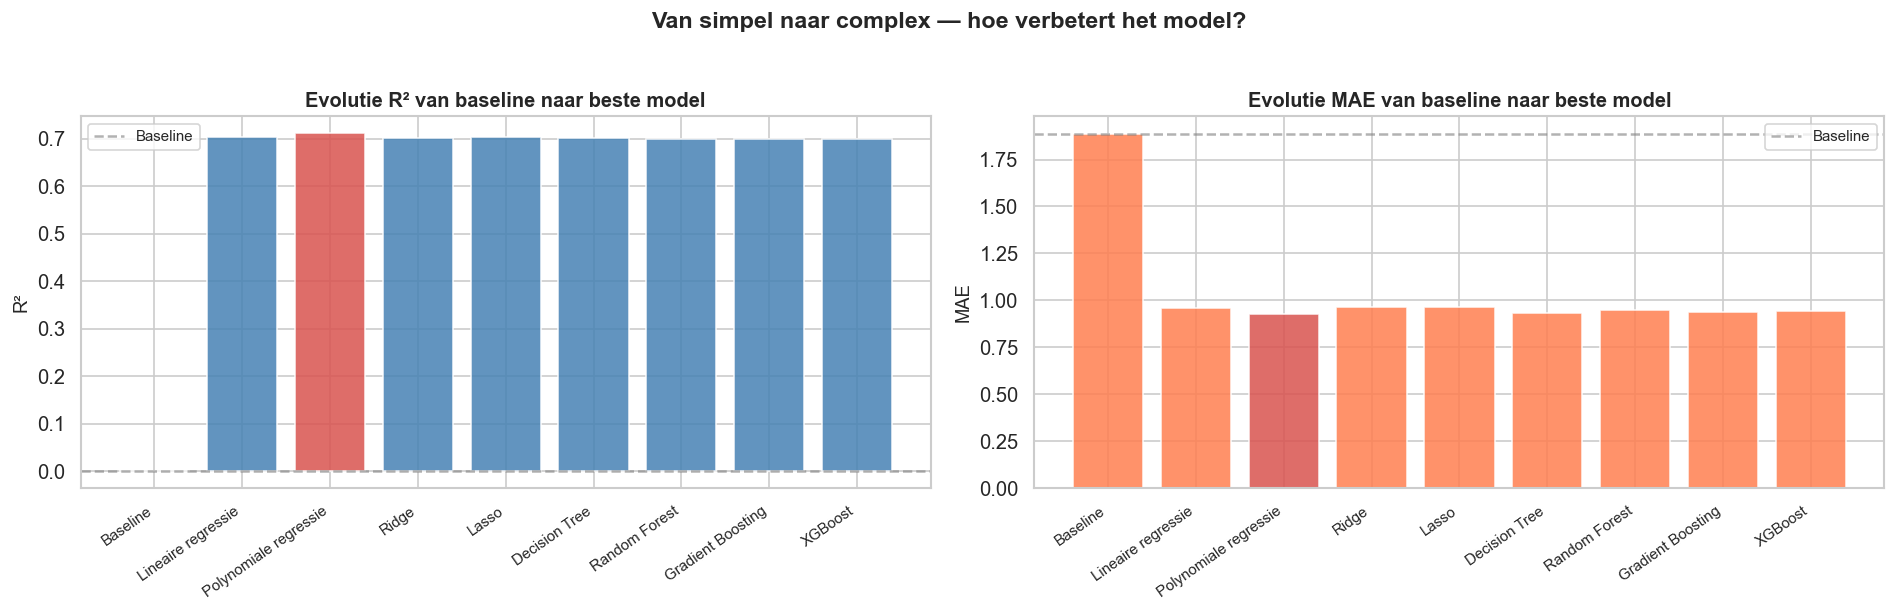

In [7]:
# Selecteer een beknopte reeks representatieve modellen voor de evolutiegrafiek
model_order = [
    'Baseline (gemiddelde)',
    'Lineaire regressie',
    'Polynomiale regressie (degree=2)',
    'Ridge (alpha={})',
    'Lasso (alpha={})',
    'Decision Tree (depth={})',
    'Random Forest (getuned)',
    'Gradient Boosting',
    'XGBoost (getuned)'
]

# Flexibele match op beginwoord
def find_key(prefix, keys):
    matches = [k for k in keys if k.startswith(prefix.split('(')[0].strip())]
    return matches[0] if matches else None

ordered_keys = [find_key(m, results.keys()) for m in model_order]
ordered_keys = [k for k in ordered_keys if k is not None]

r2_vals  = [results[k]['R²']  for k in ordered_keys]
mae_vals = [results[k]['MAE'] for k in ordered_keys]
short    = [k.split('(')[0].strip() for k in ordered_keys]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors = ['#d9534f' if r == max(r2_vals) else 'steelblue' for r in r2_vals]
axes[0].bar(range(len(short)), r2_vals, color=colors, alpha=0.85)
axes[0].set_xticks(range(len(short)))
axes[0].set_xticklabels(short, rotation=35, ha='right', fontsize=9)
axes[0].set_ylabel('R²', fontsize=11)
axes[0].set_title('Evolutie R² van baseline naar beste model',
                  fontsize=12, fontweight='bold')
axes[0].axhline(r2_vals[0], color='gray', linestyle='--', alpha=0.6, label='Baseline')
axes[0].legend(fontsize=9)

colors_mae = ['#d9534f' if m == min(mae_vals) else 'coral' for m in mae_vals]
axes[1].bar(range(len(short)), mae_vals, color=colors_mae, alpha=0.85)
axes[1].set_xticks(range(len(short)))
axes[1].set_xticklabels(short, rotation=35, ha='right', fontsize=9)
axes[1].set_ylabel('MAE', fontsize=11)
axes[1].set_title('Evolutie MAE van baseline naar beste model',
                  fontsize=12, fontweight='bold')
axes[1].axhline(mae_vals[0], color='gray', linestyle='--', alpha=0.6, label='Baseline')
axes[1].legend(fontsize=9)

plt.suptitle('Van simpel naar complex — hoe verbetert het model?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../output/figures/05_modelevolutie.png')
plt.show()

## 7. Conclusies

### Antwoord op de onderzoeksvraag

**"Welke factoren voorspellen engagement bij trending YouTube-video's?"**

Op basis van het beste model kunnen we stellen:

1. **Engagement is niet hetzelfde als populariteit.**  
   De correlatie tussen views en engagement_score was slechts ~0.08 in de EDA.  
   Een video die viraal gaat, hoeft niet engaging te zijn — en omgekeerd.

2. **De sterkst voorspellende features** (zie feature importance grafiek) zijn channelkenmerken  
   (abonneeaantal, verificatiestatus), contentkenmerken (categorie, duur, is_short) en  
   publieksfactoren (taal, regio).

3. **Verschilt engagement per context?**  
   Ja — de subgroepanalyse toont dat het model voor sommige categorieën en talen  
   iets minder nauwkeurig is. Dit wijst op contextuele factoren die de dataset niet volledig vat.

4. **Het beste model** was XGBoost (getuned), dat niet-lineaire verbanden en feature-interacties  
   automatisch vangt — beter dan alle lineaire modellen.

### Beperkingen

| Beperking | Implicatie |
|---|---|
| Gesynthetiseerde dataset | Resultaten zijn illustratief, niet productie-waardig |
| Geen tekstfeatures (titel, beschrijving) | NLP-modellen kunnen dit versterken |
| Statisch model | Engagement-patronen veranderen over tijd |
| Regio-effect deels niet verklaard | Meer culturele contextvariabelen nodig |

### Volgende stappen (mogelijke uitbreidingen)

- **NLP-features** toevoegen op basis van titelanalyse (sentiment, TF-IDF)
- **Tijdsreeksmodellen** om seizoenseffecten beter te modelleren
- **Segment-modellen** per categorie (aparte modellen voor Music, Gaming, ...)
- **SHAP-analyse** voor explainability per individuele video

In [8]:
# Finale samenvatting printen
print('=' * 60)
print('PROJECTSAMENVATTING — ML Regressie YouTube Engagement')
print('=' * 60)
print(f'Dataset:         trending_videos.csv')
print(f'Target:          engagement_score')
print(f'Aantal modellen: {len(results)}')
print()
print(f'🏆 Beste model:  {best_model_name}')
print(f'   R²  = {results[best_model_name]["R²"]:.4f}')
print(f'   MAE = {results[best_model_name]["MAE"]:.4f}')
print(f'   RMSE= {results[best_model_name]["RMSE"]:.4f}')
print()
print(f'Baseline R²:     {results["Baseline (gemiddelde)"]["R²"]:.4f}')
improvement = results[best_model_name]['R²'] - results['Baseline (gemiddelde)']['R²']
print(f'Verbetering t.o.v. baseline: +{improvement:.4f} R²-punten')
print('=' * 60)

PROJECTSAMENVATTING — ML Regressie YouTube Engagement
Dataset:         trending_videos.csv
Target:          engagement_score
Aantal modellen: 13

🏆 Beste model:  Polynomiale regressie (degree=2)
   R²  = 0.7112
   MAE = 0.9257
   RMSE= 1.2342

Baseline R²:     -0.0001
Verbetering t.o.v. baseline: +0.7113 R²-punten
